In [2]:
# =====================================================================
# STEP 1: MOUNT GOOGLE DRIVE AND EXTRACT DATASETS
# =====================================================================
import os
import zipfile
from google.colab import drive

# Mount Google Drive to access your files
drive.mount('/content/drive')
print("Google Drive mounted successfully! ✅")

# Define target dataset workspace directory
extract_path = '/content/dataset'

# Locate and extract the Test Dataset archive
test_zip = '/content/drive/MyDrive/test.zip'
if os.path.exists(test_zip):
    with zipfile.ZipFile(test_zip, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Test data unzipped successfully! ✅")
else:
    print(f"Warning: Test zip file not found at path: {test_zip}")

# Locate and extract the Training Dataset archive
train_zip = '/content/drive/MyDrive/train.zip'
if os.path.exists(train_zip):
    with zipfile.ZipFile(train_zip, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Train data unzipped successfully! ✅")
else:
    print(f"Warning: Train zip file not found at path: {train_zip}")

# Verify extracted workspace files
print("\nExtracted files in workspace directory:")
if os.path.exists(extract_path):
    for file in os.listdir(extract_path):
        print(f" - {file}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully! ✅
Test data unzipped successfully! ✅
Train data unzipped successfully! ✅

Extracted files in workspace directory:
 - training.1600000.processed.noemoticon.csv
 - twitter_dataset.csv


In [3]:
# =====================================================================
# STEP 2: IMPORT DEPENDENCIES AND CORE LIBRARIES
# =====================================================================
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Natural Language Toolkit (NLTK) assets downloading
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords

# Scikit-Learn Model Selection and Validation Engine
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All processing libraries and machine learning dependencies imported successfully! ✅")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All processing libraries and machine learning dependencies imported successfully! ✅


In [4]:
# =====================================================================
# STEP 3: DATASET LOADING AND PROFILE EXPLORATION
# =====================================================================
train_path = '/content/dataset/training.1600000.processed.noemoticon.csv'
test_path = '/content/dataset/twitter_dataset.csv'

if os.path.exists(train_path) and os.path.exists(test_path):
    # Load dataset using ISO encoding to preserve characters; disable low-memory constraints
    train_df = pd.read_csv(train_path, encoding='ISO-8859-1', header=None, low_memory=False)
    test_df = pd.read_csv(test_path, encoding='ISO-8859-1', header=None, low_memory=False)

    print("Training Dataset Shape:", train_df.shape)
    print("Testing Dataset Shape :", test_df.shape)
    print("\nInitial Dataframe Structure Preview:\n", train_df.head(2))
    print("\nMissing Data Summary across features:\n", train_df.isnull().sum())
    print("\nTarget Class Distribution Matrix (Column 0):\n", train_df[0].value_counts())
else:
    print("Error: Input datasets not found. Please re-verify the file unzipping path structures.")

Training Dataset Shape: (1600000, 6)
Testing Dataset Shape : (3142404, 3)

Initial Dataframe Structure Preview:
    0           1                             2         3                4  \
0  0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY  _TheSpecialOne_   
1  0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY    scotthamilton   

                                                   5  
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1  is upset that he can't update his Facebook by ...  

Missing Data Summary across features:
 0    0
1    0
2    0
3    0
4    0
5    0
dtype: int64

Target Class Distribution Matrix (Column 0):
 0
0    800000
4    800000
Name: count, dtype: int64


In [5]:
# =====================================================================
# STEP 4: LINGUISTIC TEXT MINING PREPROCESSING
# =====================================================================
# Renaming structure attributes to intuitive semantic labels
train_df.columns = ['target', 'id', 'date', 'flag', 'user', 'tweet']
if len(test_df.columns) == 3:
    test_df.columns = ['id', 'tweet', 'unused']

# Define the NLTK stop words set
stop_words = set(stopwords.words('english'))

def clean_tweet(text):
    text = str(text).lower()                             # 1. Normalize case to lowercase
    text = re.sub(r'http\S+|www\S+', '', text)          # 2. Extract and remove web hyperlinks
    text = re.sub(r'@\w+', '', text)                    # 3. Strip user social platform handles (@mentions)
    text = re.sub(r'#\w+', '', text)                    # 4. Remove standalone hashtags and tracking structures
    text = re.sub(r'[^a-z\s]', '', text)                # 5. Filter numbers, special characters, and punctuation symbols
    text = re.sub(r'\s+', ' ', text).strip()            # 6. Compress duplicate whitespaces to single spacing
    words = text.split()
    words = [w for w in words if w not in stop_words]   # 7. Drop high-frequency non-semantic stopwords
    return ' '.join(words)

# Execute the textual engineering cleaning logic over datasets
print("Executing text cleaning algorithms on corpus columns (This operation may take a moment)...")
train_df['clean_tweet'] = train_df['tweet'].apply(clean_tweet)
test_df['clean_tweet'] = test_df['tweet'].apply(clean_tweet)

print("\nText cleaning operation complete! Evaluation Sample:")
print(" -> Original Raw Tweet :", train_df['tweet'].iloc[0])
print(" -> Processed Clean Tweet:", train_df['clean_tweet'].iloc[0])

Executing text cleaning algorithms on corpus columns (This operation may take a moment)...

Text cleaning operation complete! Evaluation Sample:
 -> Original Raw Tweet : @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D
 -> Processed Clean Tweet: thats bummer shoulda got david carr third day


Extracting baseline TF-IDF metrics (Vocabulary limit = 5,000 | Feature Range: Unigrams)...
Fitting Baseline Logistic Regression Estimator...
Baseline estimator fitting operation successful! ✅

Baseline Configuration Metric Reports:
Baseline Testing Accuracy: 0.36872903818546865


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_


Classification Matrix Metrics Report:
               precision    recall  f1-score   support

           0       0.79      0.74      0.76   1570067
           1       0.00      0.00      0.00   1561529
           2       0.00      0.00      0.00     10725
           4       0.00      0.00      0.00         0

    accuracy                           0.37   3142321
   macro avg       0.20      0.18      0.19   3142321
weighted avg       0.39      0.37      0.38   3142321



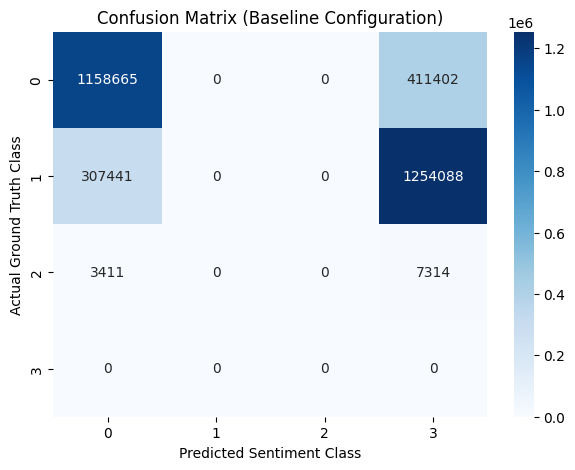

In [6]:
# =====================================================================
# STEP 5: BASELINE FEATURE VECTORIZATION & BENCHMARK EVALUATION
# =====================================================================
print("Extracting baseline TF-IDF metrics (Vocabulary limit = 5,000 | Feature Range: Unigrams)...")
baseline_vectorizer = TfidfVectorizer(max_features=5000)
X_train_base = baseline_vectorizer.fit_transform(train_df['clean_tweet'])
y_train_base = train_df['target']

# Initializing Baseline Logistic Regression Classifier
print("Fitting Baseline Logistic Regression Estimator...")
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_base, y_train_base)
print("Baseline estimator fitting operation successful! ✅")

# Transformation and Prediction Inference over testing validation split
X_test_base = baseline_vectorizer.transform(test_df['clean_tweet'])
y_pred_base = baseline_model.predict(X_test_base)

# Align validation ground truth configurations
test_df['target_clean'] = pd.to_numeric(test_df['unused'], errors='coerce')
mask = test_df['target_clean'].notna()

if mask.sum() > 0:
    y_test_filtered = test_df.loc[mask, 'target_clean'].astype(int)
    y_pred_filtered = y_pred_base[mask]

    print("\nBaseline Configuration Metric Reports:")
    print("Baseline Testing Accuracy:", accuracy_score(y_test_filtered, y_pred_filtered))
    print("\nClassification Matrix Metrics Report:\n", classification_report(y_test_filtered, y_pred_filtered))

    # Generate Baseline Confusion Matrix Heatmap
    cm = confusion_matrix(y_test_filtered, y_pred_filtered)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix (Baseline Configuration)')
    plt.xlabel('Predicted Sentiment Class')
    plt.ylabel('Actual Ground Truth Class')
    plt.show()
else:
    print("Inference notice: Evaluation ground truth data tags are not accessible in the dataset metadata.")

Generating Positive Sentiment Corpus Token Cloud...


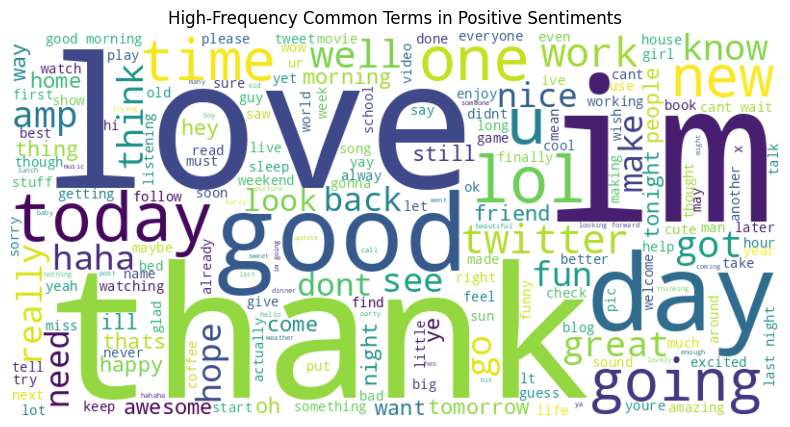

In [7]:
# =====================================================================
# STEP 6: POSITIVE SENTIMENT VOCABULARY WORDCLOUD VISUALIZATION
# =====================================================================
print("Generating Positive Sentiment Corpus Token Cloud...")
# Sampling dataset positive values to optimize execution speed
positive_words_sample = ' '.join(train_df[train_df['target'] == 4]['clean_tweet'].head(20000))

if len(positive_words_sample.strip()) > 0:
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_words_sample)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('High-Frequency Common Terms in Positive Sentiments')
    plt.show()
else:
    print("Notice: Sample collection slice is empty or positive classifications match structural variations.")

In [8]:
# =====================================================================
# STEP 7: ITERATIVE RE-ENGINEERING & MODEL OPTIMIZATION PIPELINE
# =====================================================================
print("--- Launching Advanced Model Optimization Stage ---")

# 1. Standardize target variables to proper binary integer structures ({0, 4} -> {0, 1})
train_df['target'] = train_df['target'].map({0: 0, 4: 1})
print("Re-mapped Class Configuration Profile:\n", train_df['target'].value_counts())

# 2. Synchronize re-cleaned training inputs for validation uniformity
train_df['clean_tweet'] = train_df['tweet'].apply(clean_tweet)

# 3. Structural Advanced Vectorization Tuning
# Upgrading vocabulary limit, initializing phrase scope context (Bigrams), applying log scale sublinear TF weights
print("\nExtracting High-Fidelity Features (Limit: 10,000 | N-Grams: Unigrams & Bigrams (1,2) | Sublinear TF: Enabled)...")
optimized_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2), sublinear_tf=True)

X_train_opt = optimized_vectorizer.fit_transform(train_df['clean_tweet'])
y_train_opt = train_df['target']

# 4. Hyperparameter tuning on solver coefficients (Lowering regularization barriers with inverse scaling C=5)
print("Training Optimized High-Precision Logistic Regression Classifier (C=5)...")
optimized_model = LogisticRegression(max_iter=1000, C=5)
optimized_model.fit(X_train_opt, y_train_opt)

# Evaluate Training Performance Index
y_pred_train_opt = optimized_model.predict(X_train_opt)
opt_train_acc = accuracy_score(y_train_opt, y_pred_train_opt)
print(f"\nOptimization Phase Complete! Training Convergence Accuracy Score: {opt_train_acc * 100:.2f}% ✅")

--- Launching Advanced Model Optimization Stage ---
Re-mapped Class Configuration Profile:
 target
0    800000
1    800000
Name: count, dtype: int64

Extracting High-Fidelity Features (Limit: 10,000 | N-Grams: Unigrams & Bigrams (1,2) | Sublinear TF: Enabled)...
Training Optimized High-Precision Logistic Regression Classifier (C=5)...

Optimization Phase Complete! Training Convergence Accuracy Score: 78.85% ✅


In [9]:
# =====================================================================
# STEP 8: LIVE SENTIMENT INFERENCE ENGINE & LINGUISTIC STRESS TESTING
# =====================================================================

def predict_live_sentiment(sentence):
    """Parses, vectorizes, and infers sentiment over ad-hoc input strings."""
    cleaned_txt = clean_tweet(sentence)
    vectorized_txt = optimized_vectorizer.transform([cleaned_txt])
    prediction_idx = optimized_model.predict(vectorized_txt)[0]

    if prediction_idx == 1:
        return "😊 POSITIVE"
    else:
        return "😞 NEGATIVE"

# Array configuration holding complex linguistic syntax and conversational slang expressions
stress_test_sentences = [
    # 😏 Sarcastic and Ironic Statements
    "Oh great, another Monday. Just what I needed.",
    "Wow, I just love being stuck in traffic for 3 hours!",
    "Yeah sure, losing my wallet was the best thing ever.",
    "Oh fantastic, my phone died right when I needed it most.",

    # 🔀 Negation Structures (Tests if Bigram dependencies flip classifications successfully)
    "I don't hate this at all.",
    "This is not bad.",
    "I can't say I'm unhappy about this.",
    "Not the worst experience I've ever had.",

    # 😐 Mixed Emotional Context
    "The food was amazing but the service was terrible.",
    "I love the design but hate how slow it is.",
    "Great movie, horrible ending.",
    "Best day of my life until everything went wrong.",

    # 🤔 Ambiguous Context Statements
    "It is what it is.",
    "I have no words for this.",
    "This is something else.",
    "Well... that happened.",

    # 😂 Irony and Distress Expressions
    "Sure, because my life wasn't complicated enough already.",
    "Oh wow, they cancelled my favorite show. Amazing.",
    "Brilliant. Just brilliant. Everything is on fire.",

    # 💬 Social Platform Slang Vernacular
    "This is lowkey fire ngl.",
    "That movie was so bad it was good.",
    "I'm dead 😂😂😂",
    "Bro this is actually sick!",

    # 😢 Subtle Sadness Transitions
    "I smiled today. It felt strange.",
    "I'm fine. Everything is fine.",
    "It's okay. I'm used to being disappointed.",
]

print("="*75)
print("      EXECUTING ADVANCED PIPELINE LINGUISTIC STRESS BENCHMARKS")
print("="*75)
for test_phrase in stress_test_sentences:
    prediction_result = predict_live_sentiment(test_phrase)
    print(f"📝 Input string: '{test_phrase}'\n   Classification Inference -> {prediction_result}\n")
print("="*75)

      EXECUTING ADVANCED PIPELINE LINGUISTIC STRESS BENCHMARKS
📝 Input string: 'Oh great, another Monday. Just what I needed.'
   Classification Inference -> 😞 NEGATIVE

📝 Input string: 'Wow, I just love being stuck in traffic for 3 hours!'
   Classification Inference -> 😞 NEGATIVE

📝 Input string: 'Yeah sure, losing my wallet was the best thing ever.'
   Classification Inference -> 😊 POSITIVE

📝 Input string: 'Oh fantastic, my phone died right when I needed it most.'
   Classification Inference -> 😞 NEGATIVE

📝 Input string: 'I don't hate this at all.'
   Classification Inference -> 😞 NEGATIVE

📝 Input string: 'This is not bad.'
   Classification Inference -> 😞 NEGATIVE

📝 Input string: 'I can't say I'm unhappy about this.'
   Classification Inference -> 😞 NEGATIVE

📝 Input string: 'Not the worst experience I've ever had.'
   Classification Inference -> 😞 NEGATIVE

📝 Input string: 'The food was amazing but the service was terrible.'
   Classification Inference -> 😞 NEGATIVE

📝 Input s